In [2]:
from pathlib import Path

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt

from nbtools import auto_plot_style
from nbtools import normhist, normhist2d

In [3]:
auto_plot_style()

In [6]:
rbins     = np.linspace(  0, 16, 81)
xybins    = np.linspace(-16, 16, 81)
drbins_bb = np.linspace(  0, 12, 81)
drbins_nn = np.linspace(  0, 3, 81)

In [18]:
def profile(df, n):
    binsize = 16 / n
    binid = df.r0 // binsize
    out   = df.groupby(binid).agg( bb_mean = pd.NamedAgg(column="dr_bb", aggfunc="mean")
                                 , bb_std  = pd.NamedAgg(column="dr_bb", aggfunc="std" )
                                 , nn_mean = pd.NamedAgg(column="dr_nn", aggfunc="mean")
                                 , nn_std  = pd.NamedAgg(column="dr_nn", aggfunc="std" )
                                 )
    out.insert(0, "ur0", binsize / 2)
    out.insert(0,  "r0", (out.index + 0.5) * binsize)
    return out.reset_index(drop=True)

# Fixed wire diameter: 10 $\mu$m

In [4]:
path3_20 = Path("../data/pcolina/3x3/0.20/10um/reco.h5")
path3_65 = Path("../data/pcolina/3x3/0.65/10um/reco.h5")
path6_50 = Path("../data/pcolina/6x6/0.50/10um/reco.h5")
path3_20.exists(), path3_65.exists(), path6_50.exists()

(True, True, True)

In [5]:
data3_20 = pd.read_hdf(path3_20)
data3_65 = pd.read_hdf(path3_65)
data6_50 = pd.read_hdf(path6_50)

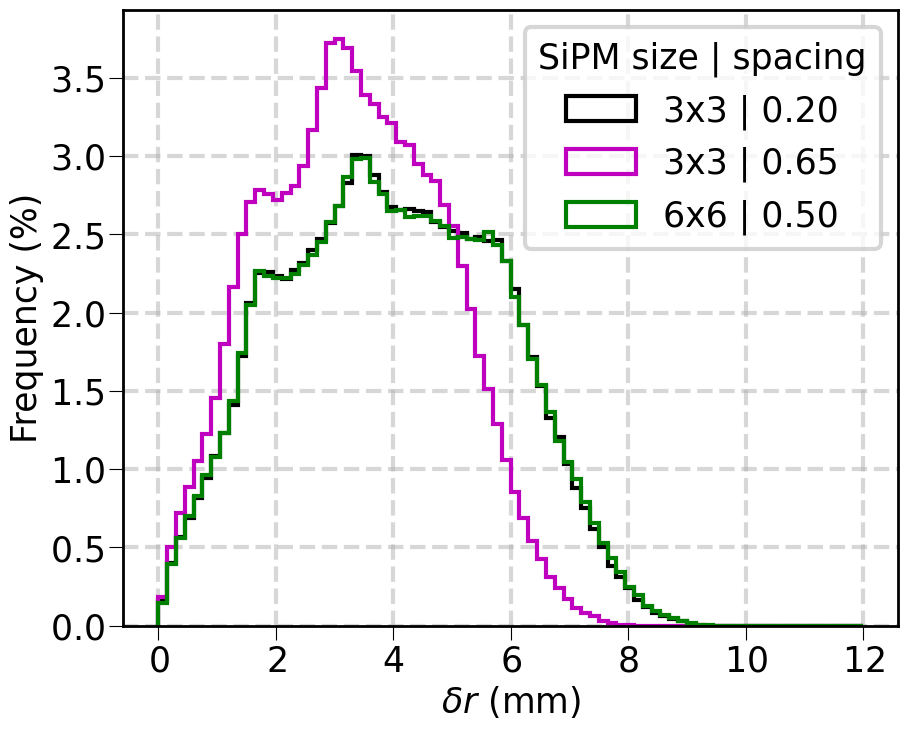

In [7]:
normhist(data3_20.dr_bb, drbins_bb, label="3x3 | 0.20")
normhist(data3_65.dr_bb, drbins_bb, label="3x3 | 0.65")
normhist(data6_50.dr_bb, drbins_bb, label="6x6 | 0.50")
plt.xlabel("$\delta r$ (mm)")
plt.ylabel("Frequency (%)")
plt.legend(title="SiPM size | spacing")
plt.grid()

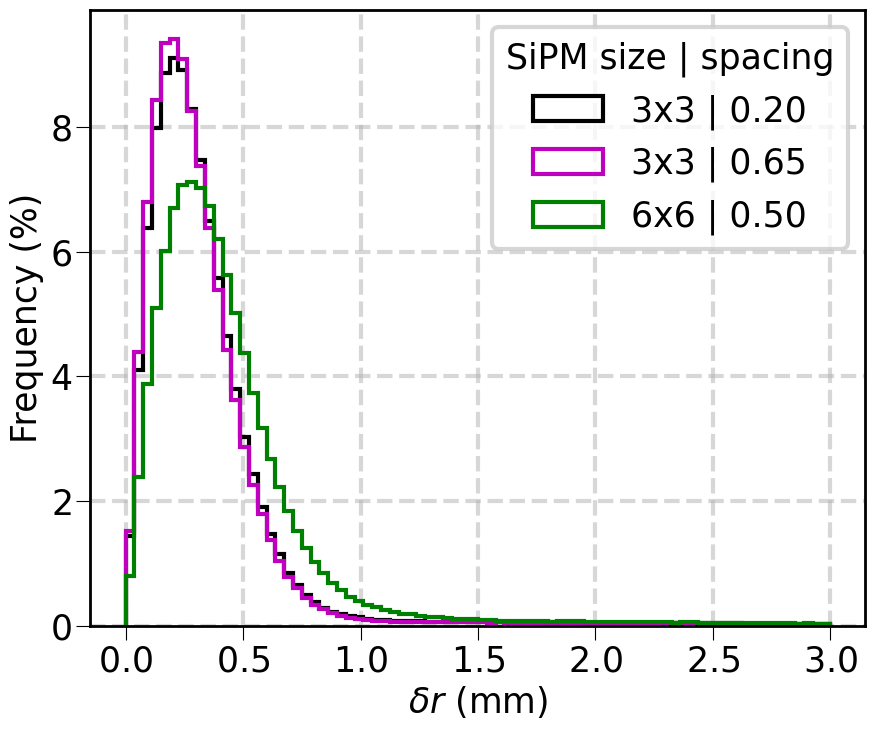

In [8]:
normhist(data3_20.dr_nn, drbins_nn, label="3x3 | 0.20")
normhist(data3_65.dr_nn, drbins_nn, label="3x3 | 0.65")
normhist(data6_50.dr_nn, drbins_nn, label="6x6 | 0.50")
plt.xlabel("$\delta r$ (mm)")
plt.ylabel("Frequency (%)")
plt.legend(title="SiPM size | spacing")
plt.grid()

In [10]:
profs3_20 = profile(data3_20, 26)
profs3_65 = profile(data3_65, 26)
profs6_50 = profile(data6_50, 26)

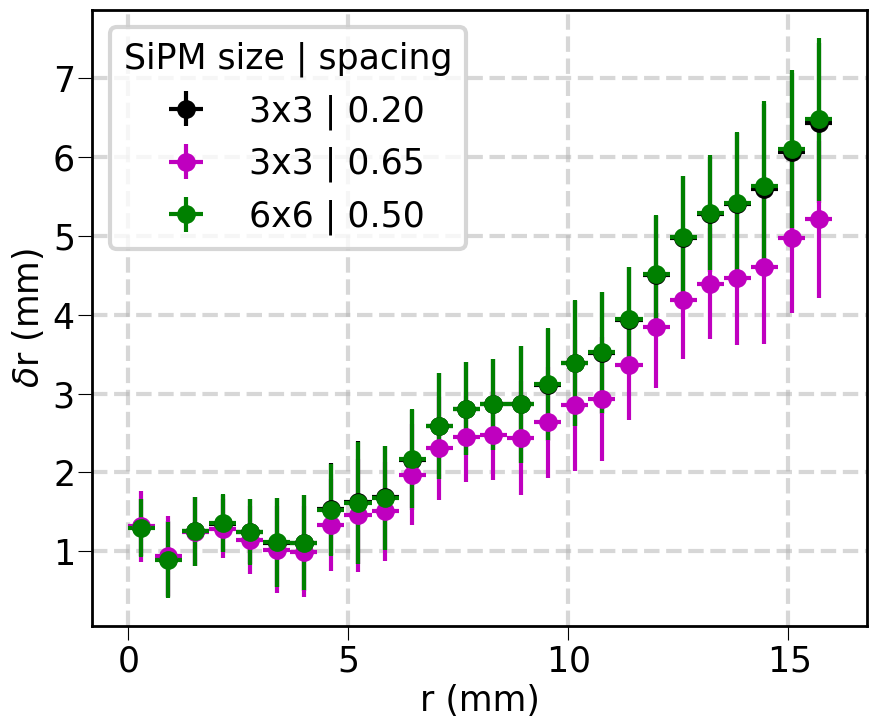

In [11]:
df=profs3_20;plt.errorbar(df.r0, df.bb_mean, df.bb_std, df.ur0, fmt=".", label="3x3 | 0.20")
df=profs3_65;plt.errorbar(df.r0, df.bb_mean, df.bb_std, df.ur0, fmt=".", label="3x3 | 0.65")
df=profs6_50;plt.errorbar(df.r0, df.bb_mean, df.bb_std, df.ur0, fmt=".", label="6x6 | 0.50")
plt.xlabel("r (mm)")
plt.ylabel("$\delta$r (mm)")
plt.legend(title="SiPM size | spacing")
plt.grid()

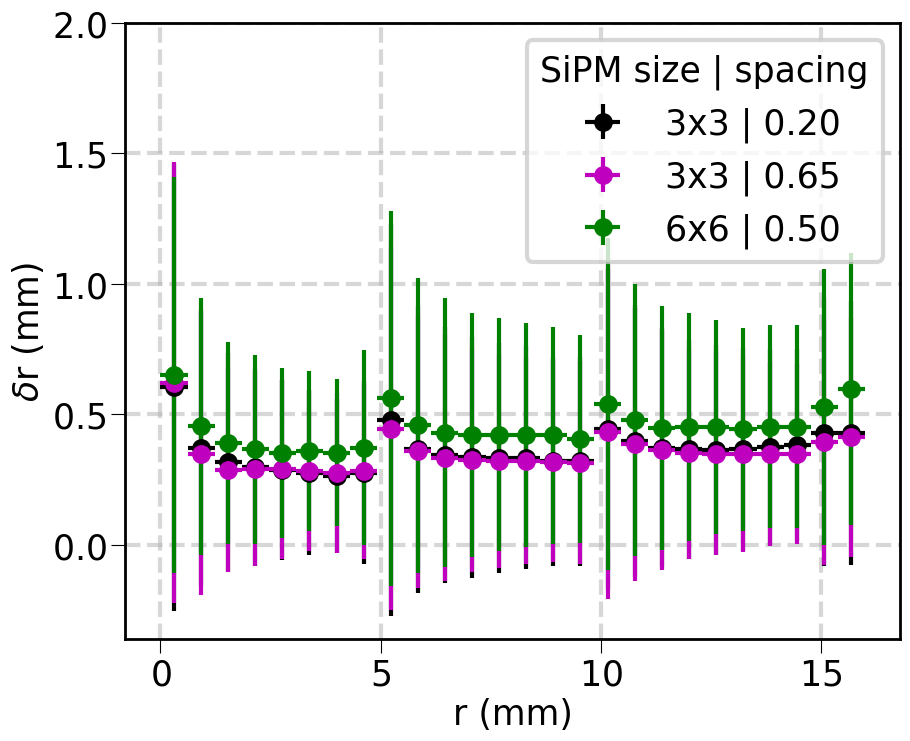

In [12]:
df=profs3_20;plt.errorbar(df.r0, df.nn_mean, df.nn_std, df.ur0, fmt=".", label="3x3 | 0.20")
df=profs3_65;plt.errorbar(df.r0, df.nn_mean, df.nn_std, df.ur0, fmt=".", label="3x3 | 0.65")
df=profs6_50;plt.errorbar(df.r0, df.nn_mean, df.nn_std, df.ur0, fmt=".", label="6x6 | 0.50")
plt.xlabel("r (mm)")
plt.ylabel("$\delta$r (mm)")
plt.legend(title="SiPM size | spacing")
plt.ylim(None, 2)
plt.grid()

# Compare wire diameters

In [13]:
path05 = Path("../data/pcolina/6x6/0.50/5um/reco.h5")
path10 = Path("../data/pcolina/6x6/0.50/10um/reco.h5")
path18 = Path("../data/pcolina/6x6/0.50/18um/reco.h5")
path25 = Path("../data/pcolina/6x6/0.50/25um/reco.h5")
path05.exists(), path10.exists(), path18.exists(), path25.exists()

(True, True, True, True)

In [14]:
data05 = pd.read_hdf(path05)
data10 = pd.read_hdf(path10)
data18 = pd.read_hdf(path18)
data25 = pd.read_hdf(path25)

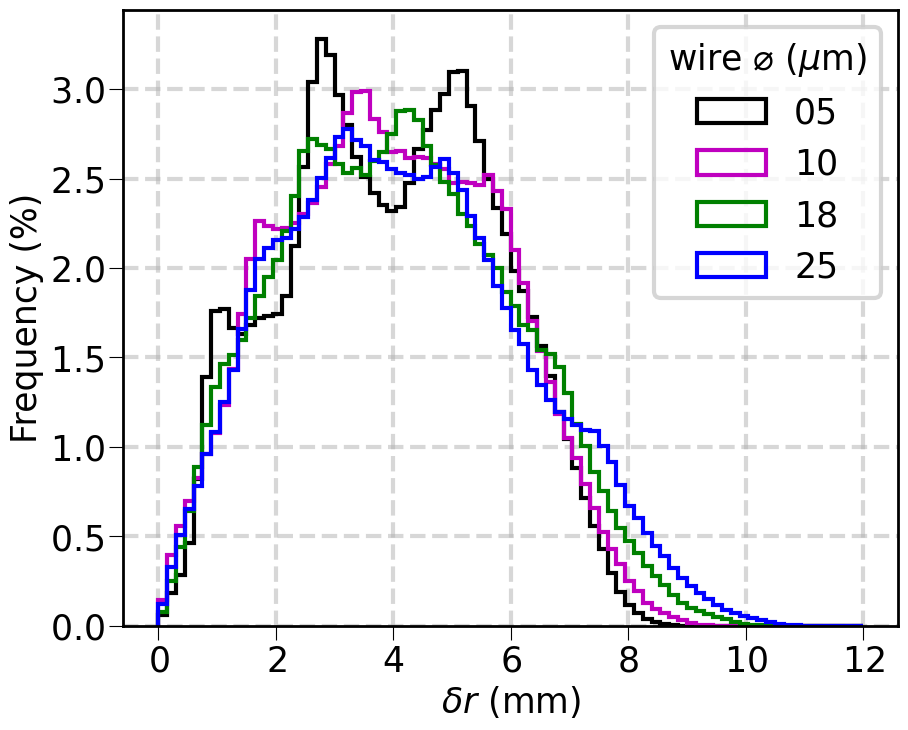

In [16]:
normhist(data05.dr_bb, drbins_bb, label="05")
normhist(data10.dr_bb, drbins_bb, label="10")
normhist(data18.dr_bb, drbins_bb, label="18")
normhist(data25.dr_bb, drbins_bb, label="25")
plt.xlabel("$\delta r$ (mm)")
plt.ylabel("Frequency (%)")
plt.legend(title="wire ⌀ ($\mu$m)")
plt.grid()

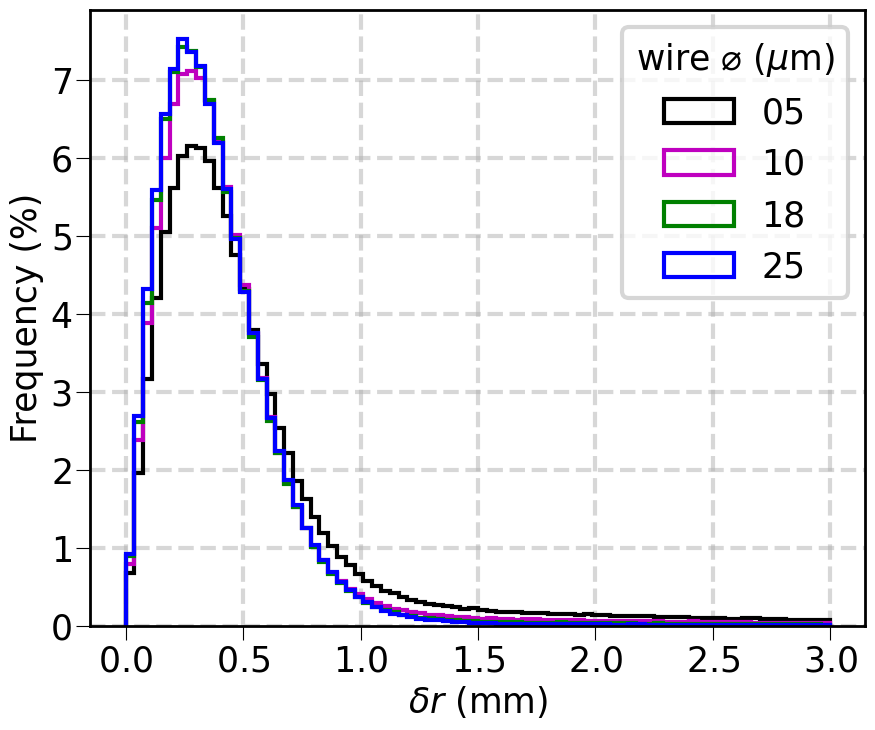

In [17]:
normhist(data05.dr_nn, drbins_nn, label="05")
normhist(data10.dr_nn, drbins_nn, label="10")
normhist(data18.dr_nn, drbins_nn, label="18")
normhist(data25.dr_nn, drbins_nn, label="25")
plt.xlabel("$\delta r$ (mm)")
plt.ylabel("Frequency (%)")
plt.legend(title="wire ⌀ ($\mu$m)")
plt.grid()

In [22]:
profs05 = profile(data05, 11)
profs10 = profile(data10, 11)
profs18 = profile(data18, 11)
profs25 = profile(data25, 11)

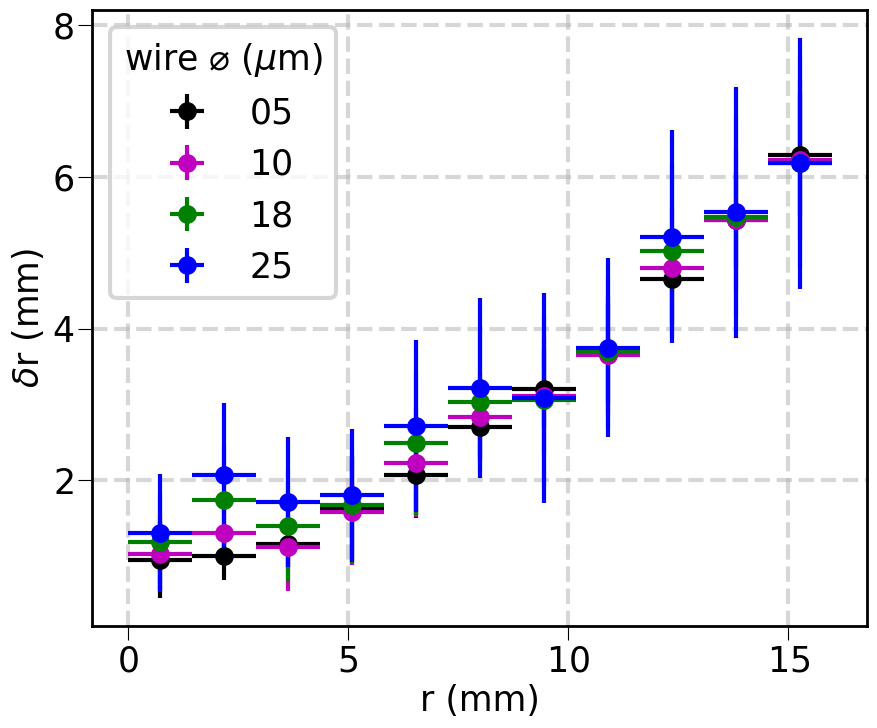

In [23]:
df=profs05;plt.errorbar(df.r0, df.bb_mean, df.bb_std, df.ur0, fmt=".", label="05")
df=profs10;plt.errorbar(df.r0, df.bb_mean, df.bb_std, df.ur0, fmt=".", label="10")
df=profs18;plt.errorbar(df.r0, df.bb_mean, df.bb_std, df.ur0, fmt=".", label="18")
df=profs25;plt.errorbar(df.r0, df.bb_mean, df.bb_std, df.ur0, fmt=".", label="25")

plt.xlabel("r (mm)")
plt.ylabel("$\delta$r (mm)")
plt.legend(title="wire ⌀ ($\mu$m)")
plt.grid()

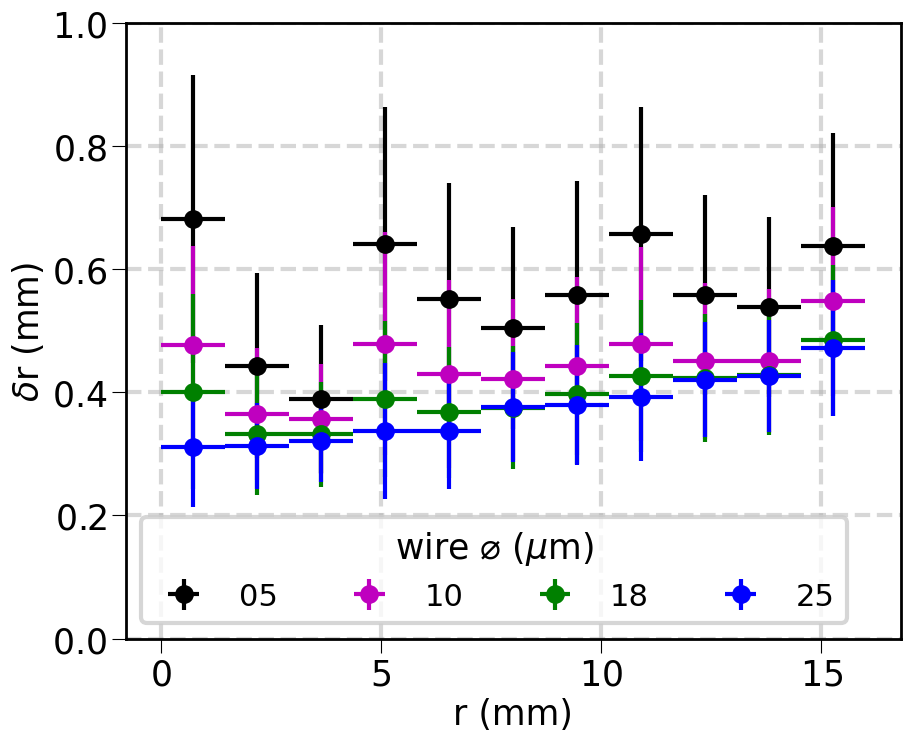

In [34]:
df=profs05;plt.errorbar(df.r0, df.nn_mean, df.nn_std / len(df)**0.5, df.ur0, fmt=".", label="05")
df=profs10;plt.errorbar(df.r0, df.nn_mean, df.nn_std / len(df)**0.5, df.ur0, fmt=".", label="10")
df=profs18;plt.errorbar(df.r0, df.nn_mean, df.nn_std / len(df)**0.5, df.ur0, fmt=".", label="18")
df=profs25;plt.errorbar(df.r0, df.nn_mean, df.nn_std / len(df)**0.5, df.ur0, fmt=".", label="25")
plt.ylim(0, 1)
plt.xlabel("r (mm)")
plt.ylabel("$\delta$r (mm)")
plt.legend(loc="lower left", title="wire ⌀ ($\mu$m)", ncol=4, fontsize=22)
plt.grid()